In [1]:
import ast
import os
from datetime import datetime
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AdamW, AutoTokenizer, AutoModelForTokenClassification, AutoConfig
from torchcrf import CRF 
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:

from datasets import load_dataset, load_from_disk
#from transformers import Trainer, TrainingArguments
from seqeval.metrics import accuracy_score, f1_score, precision_score, recall_score

In [3]:
from datasets import load_from_disk

In [4]:
ROOTDIR="/Users/pals/MICS/MIDS_266/project/privacy-ner-att"
MODEL   = "privacy_model"
OUTDIR  = f"{ROOTDIR}/build/{MODEL}/results"
LOGDIR  = f"{ROOTDIR}/build/{MODEL}/logs"
SAVEDIR = f"{ROOTDIR}/build/{MODEL}/checkpoints"
DEBUG   = True

In [5]:
def get_logger(log_dir, debug):
    if not debug or not log_dir:
        return None  # Logging disabled

    os.makedirs(log_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_path = os.path.join(log_dir, f"privacy_attend_training_{timestamp}.log")
    return open(log_path, "w")  # Keep this open during full training session


In [6]:
logger = get_logger(LOGDIR, DEBUG)

In [7]:
def logprint(logger, msgstr):
    if logger:
        logger.write(msgstr+"\n")

In [8]:
logprint(logger, f"start of training.")

In [9]:

dataset_name=f"{ROOTDIR}/datasets/hf_expanded_privacy_dataset_v2"

In [10]:
dataset = load_from_disk(dataset_name)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'bio_tags', 'privacy_class_label', '__index_level_0__'],
        num_rows: 3000
    })
    validation: Dataset({
        features: ['text', 'bio_tags', 'privacy_class_label', '__index_level_0__'],
        num_rows: 600
    })
    test: Dataset({
        features: ['text', 'bio_tags', 'privacy_class_label', '__index_level_0__'],
        num_rows: 400
    })
})


In [11]:
model_name = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [12]:
def tokenize_and_align_labels(input_row, personal_label2id, pii_label2id, max_length=256):
    # Tokenize the input text with word alignment
    tokenized = tokenizer(
        input_row["text"],
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_offsets_mapping=True,
        return_tensors=None  # Ensure output is plain dict
    )

    # Convert bio_tags string to list of (tag, token)
    bio_tags = ast.literal_eval(input_row["bio_tags"]) if isinstance(input_row["bio_tags"], str) else input_row["bio_tags"]

    # Extract only the tag portion (e.g., "B-PER") from each (tag, word) tuple
    word_level_tags = [tag for tag, _ in bio_tags]

    word_ids = tokenized.word_ids()
    aligned_ner_labels = []
    aligned_pii_labels = []

    for word_idx in word_ids:
        if word_idx is None:
            aligned_ner_labels.append(-100)
            aligned_pii_labels.append(-100)
        else:
            tag = word_level_tags[word_idx] if word_idx < len(word_level_tags) else "O"
            ner_label = personal_label2id.get(tag, personal_label2id["O"])
            pii_label = pii_label2id.get(tag, pii_label2id["O"])
            aligned_ner_labels.append(ner_label)
            aligned_pii_labels.append(pii_label)

    tokenized.pop("offset_mapping", None)

    tokenized["labels_ner"] = aligned_ner_labels
    tokenized["labels_pii"] = aligned_pii_labels
    tokenized["labels_privacy"] = input_row["privacy_class_label"]

    return tokenized


In [13]:
import ast

# Step 1: Extract unique NER tags from bio_tags column
unique_tags = set(tag for row in dataset["train"]["bio_tags"] for tag, _ in ast.literal_eval(row))

# Step 2: Build a full sorted list (to preserve namespace and growth)
label_list = sorted(unique_tags)

# Step 3: Create personal and pii label sets from label_list
personal_tag_prefixes = {"B-PER", "I-PER"}
personal_label_set = {tag for tag in label_list if tag in personal_tag_prefixes}
pii_label_set = set(label_list) - personal_label_set

# Step 4: Add "O" tag to both sets (if not already present)
personal_label_set.add("O")
pii_label_set.add("O")

# Step 5: Convert to sorted lists
personal_label_list = sorted(personal_label_set)
pii_label_list = sorted(pii_label_set)

# Step 6: Build dense local label2id mappings
personal_label2id = {label: idx for idx, label in enumerate(personal_label_list)}
pii_label2id = {label: idx for idx, label in enumerate(pii_label_list)}
personal_id2label = {idx: label for label, idx in personal_label2id.items()}
pii_id2label = {idx: label for label, idx in pii_label2id.items()}

In [14]:
from functools import partial

# Wrap the tokenizer function with fixed label2id arguments
tokenize_fn = partial(
    tokenize_and_align_labels,
    personal_label2id=personal_label2id,
    pii_label2id=pii_label2id,
    max_length=256
)

In [15]:
column_names = dataset["train"].column_names  # Assumes all splits have same columns

tokenized_dataset = dataset.map(
    tokenize_fn,
    batched=False,
    remove_columns=column_names
)


In [16]:
sample = tokenized_dataset["train"][0]
print("Keys:", sample.keys())
print("Input shape:", len(sample["input_ids"]))
print("NER labels:", sample["labels_ner"])
print("PII labels:", sample["labels_pii"])
print("Privacy class:", sample["labels_privacy"])

Keys: dict_keys(['input_ids', 'attention_mask', 'labels_ner', 'labels_pii', 'labels_privacy'])
Input shape: 256
NER labels: [-100, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,

In [17]:
class SoftmaxNERHead(nn.Module):
    """
    Simple NER head with FF → ReLU → Dropout → Classifier → CrossEntropyLoss
    """
    def __init__(self, hidden_size, label2id, dropout_prob=0.1, expansion_factor=1):
        super().__init__()
        self.label2id = label2id
        self.id2label = {v: k for k, v in label2id.items()}
        self.num_labels = len(label2id)

        expanded_size = int(hidden_size * expansion_factor)

        self.ff = nn.Linear(hidden_size, expanded_size)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout_prob)
        self.classifier = nn.Linear(expanded_size, self.num_labels)

        self.loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

    def forward(self, sequence_output, labels=None, attention_mask=None, return_decoded=False):
        x = self.ff(sequence_output)
        x = self.activation(x)
        x = self.dropout(x)
        logits = self.classifier(x)  # [B, T, num_labels]

        loss = None
        decoded_labels = None

        if labels is not None:
            # CrossEntropyLoss expects: [B * T, num_labels], labels: [B * T]
            loss = self.loss_fn(logits.view(-1, self.num_labels), labels.view(-1))

        if return_decoded:
            predictions = torch.argmax(logits, dim=-1)  # [B, T]
            decoded_labels = [
                [self.id2label[tag_id.item()] for tag_id in seq]
                for seq in predictions
            ]

        return logits, loss, decoded_labels


In [18]:
class CRFNERHead(nn.Module):
    """
    NER classifier with optional expandable feedforward network before CRF.
    """
    def __init__(self, hidden_size, label2id, expansion_factor=1):
        super(CRFNERHead, self).__init__()
        self.label2id = label2id
        self.id2label = {v: k for k, v in label2id.items()}
        self.num_labels = len(label2id)
        self.expanded_size = int(hidden_size * expansion_factor)

        self.ff_layer = nn.Linear(hidden_size, self.expanded_size)
        self.activation = nn.ReLU()
        self.classifier = nn.Linear(self.expanded_size, self.num_labels)
        self.crf = CRF(num_tags=self.num_labels, batch_first=True)
        self.name = "layer<PER> " if self.num_labels <= 3 else "layer<PII> "
        logprint(logger, f"{self.name} lable2id: {self.label2id}")

    def forward(self, sequence_output, labels=None, attention_mask=None, return_decoded=False):
        """
        Forward pass:
        - sequence_output: (batch, seq_len, hidden_size)
        - labels: Ground truth token labels (batch, seq_len)
        - attention_mask: Padding mask (batch, seq_len)
        - return_decoded: If True, returns decoded tag strings

        Returns:
        - logits, loss (optional), decoded tags (optional)
        """
        x = self.ff_layer(sequence_output)
        x = self.activation(x)
        logits = self.classifier(x)

        mask = attention_mask.bool() if attention_mask is not None else None

        loss = None
        decoded_labels = None

        if labels is not None:
            loss = -self.crf(logits, labels, mask=mask, reduction='mean')
            logprint(logger, f"{self.name} logits shape: {logits.shape}")
            logprint(logger, f"{self.name} labels shape: {labels.shape}")

            if loss < 0:
                print(f"WARNING: Negative CRF loss: {loss.item():.4f}")
                print("Logits min/max:", logits.min().item(), logits.max().item())
                print("Label IDs used:", torch.unique(labels))
                print("Mask sums:", mask.sum(dim=1))
                print("CRF num_tags:", self.num_labels)

        if return_decoded:
            decoded_ids = self.crf.decode(logits, mask=mask)
            decoded_labels = [
                [self.id2label[tag_id] for tag_id in seq] for seq in decoded_ids
            ]

        return logits, loss, decoded_labels


In [19]:
class CrossAttentionLayer(nn.Module):
    def __init__(self, hidden_size, personal_label2id, pii_label2id):
        """
        Cross-attention between personal NER tokens and PII tokens.

        Args:
        - hidden_size: Hidden size of transformer output
        - personal_label2id: Dict for personal entity tags (e.g., B-PER, I-PER)
        - pii_label2id: Dict for privacy-sensitive tags (e.g., B-SSN, B-CONDITION)
        """
        super().__init__()
        self.query_dense = nn.Linear(hidden_size, hidden_size)
        self.key_dense = nn.Linear(hidden_size, hidden_size)
        self.value_dense = nn.Linear(hidden_size, hidden_size)

        # Derive list of relevant label IDs from input dicts
        self.personal_labels = [personal_label2id[lbl] for lbl in personal_label2id if lbl != "O"]
        self.pii_labels = [pii_label2id[lbl] for lbl in pii_label2id if lbl != "O"]

    def forward(self,
                sequence_output,               # [B, T, H]
                logits_ner=None,               # [B, T, C1]
                logits_pii=None,               # [B, T, C2]
                labels_ner=None,               # [B, T]
                labels_pii=None,               # [B, T]
                attention_mask=None):          # [B, T]

        batch_size, seq_len, hidden_dim = sequence_output.size()

        # === TRAINING MODE ===
        if labels_ner is not None and labels_pii is not None:
            personal_mask = torch.zeros_like(labels_ner, dtype=torch.float)
            pii_mask = torch.zeros_like(labels_pii, dtype=torch.float)

            for tag_id in self.personal_labels:
                personal_mask += (labels_ner == tag_id).float()
            for tag_id in self.pii_labels:
                pii_mask += (labels_pii == tag_id).float()

            personal_repr = sequence_output * personal_mask.unsqueeze(-1)
            pii_repr = sequence_output * pii_mask.unsqueeze(-1)

        # === INFERENCE MODE ===
        elif logits_ner is not None and logits_pii is not None:
            ner_probs = F.softmax(logits_ner, dim=-1)
            pii_probs = F.softmax(logits_pii, dim=-1)

            personal_probs = ner_probs[..., self.personal_labels].sum(dim=-1, keepdim=True)
            pii_probs = pii_probs[..., self.pii_labels].sum(dim=-1, keepdim=True)

            personal_repr = sequence_output * personal_probs
            pii_repr = sequence_output * pii_probs

        else:
            raise ValueError("Must provide either (labels_ner & labels_pii) or (logits_ner & logits_pii)")

        # === QKV Attention ===
        Q = self.query_dense(personal_repr)
        K = self.key_dense(pii_repr)
        V = self.value_dense(pii_repr)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (hidden_dim ** 0.5)  # [B, T, T]

        if attention_mask is not None:
            scores = scores.masked_fill(attention_mask.unsqueeze(1) == 0, float("-inf"))

        attn_weights = F.softmax(scores, dim=-1)
        attended_output = torch.matmul(attn_weights, V)

        return attended_output, attn_weights


In [20]:
class PrivacyClassificationHead(nn.Module):
    def __init__(self, hidden_size, num_classes=2, use_max_pool=True, expansion_factor=1.0):
        super().__init__()
        self.use_max_pool = use_max_pool
        self.num_classes = num_classes

        intermediate_size = int(hidden_size * expansion_factor)
        self.ff = nn.Linear(hidden_size, intermediate_size)
        self.activation = nn.ReLU()
        self.classifier = nn.Linear(intermediate_size, num_classes)
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, hidden_states, attention_mask, labels=None, return_attention=False, attention_weights=None, return_attention_weights=False):
        """
        hidden_states: [B, T, H]
        attention_mask: [B, T]
        labels: [B] → 0/1 for binary classification
        """
        if self.use_max_pool:
            masked = hidden_states.masked_fill(attention_mask.unsqueeze(-1) == 0, -1e9)
            pooled = torch.max(masked, dim=1).values  # [B, H]
        else:
            masked = hidden_states * attention_mask.unsqueeze(-1)
            pooled = torch.sum(masked, dim=1) / attention_mask.sum(dim=1, keepdim=True)  # [B, H]

        x = self.ff(pooled)  # [B, H']
        x = self.activation(x)
        logits = self.classifier(x)  # [B, num_classes]

        if labels is not None:
            loss = self.loss_fn(logits, labels)
            return logits, loss

        return logits, attention_weights if return_attention else logits


In [21]:
class PrivacyDetectionModel(nn.Module):
    def __init__(
        self,
        base_model_name: str,
        personal_label2id: dict,
        pii_label2id: dict,
        num_privacy_labels: int = 2,
        return_attention_weights: bool = False,
        expansion_factor: float = 1.0
    ):
        super().__init__()

        self.base_model = AutoModel.from_pretrained(base_model_name)
        hidden_size = self.base_model.config.hidden_size
        self.return_attention_weights = return_attention_weights

        # === NER Heads ===

        self.personal_ner_head = SoftmaxNERHead(
            hidden_size=hidden_size,
            label2id=personal_label2id,
            expansion_factor=expansion_factor
        )

        self.pii_ner_head = SoftmaxNERHead(
            hidden_size=hidden_size,
            label2id=pii_label2id,
            expansion_factor=expansion_factor
        )

        # === Cross Attention Layer ===
        self.cross_attention = CrossAttentionLayer(
            hidden_size=hidden_size,
            personal_label2id=personal_label2id,
            pii_label2id=pii_label2id
        )

        # === Final Privacy Classification Head ===
        self.classifier_head = PrivacyClassificationHead(
            hidden_size=hidden_size,
            num_classes=num_privacy_labels,
            use_max_pool=True,
            expansion_factor=expansion_factor
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        labels_ner=None,
        labels_pii=None,
        privacy_labels=None,
        return_decoded=False,
    ):
        """
        Args:
            input_ids: [B, T]
            attention_mask: [B, T]
            labels_ner: Optional [B, T]
            labels_pii: Optional [B, T]
            privacy_labels: Optional [B]
            return_decoded: Optional bool to return predicted tag strings

        Returns:
            Dict with keys: loss, logits, decoded_ner, decoded_pii, attention_weights
        """

        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # [B, T, H]

        # === NER Predictions ===
        logits_ner, loss_ner, decoded_ner = self.personal_ner_head(
            sequence_output, labels=labels_ner, attention_mask=attention_mask, return_decoded=return_decoded
        )

        logits_pii, loss_pii, decoded_pii = self.pii_ner_head(
            sequence_output, labels=labels_pii, attention_mask=attention_mask, return_decoded=return_decoded
        )

        # === Cross Attention between personal + pii tokens ===
        attended_output, attention_weights = self.cross_attention(
            sequence_output=sequence_output,
            logits_ner=logits_ner if labels_ner is None else None,
            logits_pii=logits_pii if labels_pii is None else None,
            labels_ner=labels_ner,
            labels_pii=labels_pii,
            attention_mask=attention_mask
        )

        # === Final Privacy Classification ===
        logits_privacy, loss_privacy = self.classifier_head(
            attended_output, labels=privacy_labels,
            attention_mask=attention_mask,
            return_attention_weights=self.return_attention_weights
        )
        # === Total Loss (NER + Privacy)

        total_loss = 0
        if loss_ner is not None:
            total_loss += loss_ner
        if loss_pii is not None:
            total_loss += loss_pii
        if loss_privacy is not None:
            total_loss += loss_privacy
        logprint(logger, f"loss ner: {loss_ner}, loss_pii: {loss_pii}, loss_privacy: {loss_privacy}")
        result = {
            "loss": total_loss,
            "logits_ner": logits_ner,
            "logits_pii": logits_pii,
            "logits_privacy": logits_privacy,
        }

        if return_decoded:
            result["decoded_ner"] = decoded_ner
            result["decoded_pii"] = decoded_pii

        if self.return_attention_weights:
            result["attention_weights"] = attention_weights

        return result


In [22]:
base_model_name = "answerdotai/ModernBERT-base"
privacy_model = PrivacyDetectionModel(base_model_name, personal_label2id=personal_label2id, pii_label2id=pii_label2id)
#print(privacy_model)

In [23]:
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
print(f"Loading model to device: {device}")
privacy_model.to(device)

Loading model to device: mps


PrivacyDetectionModel(
  (base_model): ModernBertModel(
    (embeddings): ModernBertEmbeddings(
      (tok_embeddings): Embedding(50368, 768, padding_idx=50283)
      (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0): ModernBertEncoderLayer(
        (attn_norm): Identity()
        (attn): ModernBertAttention(
          (Wqkv): Linear(in_features=768, out_features=2304, bias=False)
          (rotary_emb): ModernBertRotaryEmbedding()
          (Wo): Linear(in_features=768, out_features=768, bias=False)
          (out_drop): Identity()
        )
        (mlp_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): ModernBertMLP(
          (Wi): Linear(in_features=768, out_features=2304, bias=False)
          (act): GELUActivation()
          (drop): Dropout(p=0.0, inplace=False)
          (Wo): Linear(in_features=1152, out_features=768, bias=False)
        )
      )
      (

In [24]:
def custom_collate_fn(batch):
    return {
        "input_ids": torch.tensor([item["input_ids"] for item in batch], dtype=torch.long),
        "attention_mask": torch.tensor([item["attention_mask"] for item in batch], dtype=torch.long),
        "labels_ner": torch.tensor([item["labels_ner"] for item in batch], dtype=torch.long),
        "labels_pii": torch.tensor([item["labels_pii"] for item in batch], dtype=torch.long),
        "privacy_labels": torch.tensor([item["labels_privacy"] for item in batch], dtype=torch.long),
    }


In [25]:
BATCH_SIZE = 8
NUM_EPOCHS = 10
WT_DECAY = 0.01
LEARNING_RATE = 2E-5

In [26]:
def init_epoch_metrics():
    return {
        "loss_total": [],
        "acc_ner": [],
        "acc_pii": [],
        "acc_privacy": []
    }


In [27]:
train_metrics = init_epoch_metrics()
val_metrics = init_epoch_metrics()

In [28]:
def init_batch_accumulators():
    return {
        "loss_sum": 0.0,
        "correct_privacy": 0,
        "total_privacy": 0,
        "correct_ner": 0,
        "total_ner": 0,
        "correct_pii": 0,
        "total_pii": 0
    }

In [29]:
def update_batch_metrics(acc, outputs, labels_ner, labels_pii, labels_privacy):
    logits_priv = outputs["logits_privacy"]
    logits_ner = outputs["logits_ner"]
    logits_pii = outputs["logits_pii"]
    loss = outputs["loss"]

    preds_priv = torch.argmax(logits_priv, dim=-1)
    preds_ner = torch.argmax(logits_ner, dim=-1)
    preds_pii = torch.argmax(logits_pii, dim=-1)

    acc["loss_sum"] += loss.item() * labels_privacy.size(0)
    acc["correct_privacy"] += (preds_priv == labels_privacy).sum().item()
    acc["total_privacy"] += labels_privacy.size(0)

    mask_ner = labels_ner != -100
    acc["correct_ner"] += ((preds_ner == labels_ner) & mask_ner).sum().item()
    acc["total_ner"] += mask_ner.sum().item()

    mask_pii = labels_pii != -100
    acc["correct_pii"] += ((preds_pii == labels_pii) & mask_pii).sum().item()
    acc["total_pii"] += mask_pii.sum().item()


In [30]:
def finalize_epoch_metrics(acc, metrics_dict):
    n_samples = acc["total_privacy"]
    metrics_dict["loss_total"].append(acc["loss_sum"] / n_samples)
    metrics_dict["acc_privacy"].append(acc["correct_privacy"] / acc["total_privacy"])
    metrics_dict["acc_ner"].append(acc["correct_ner"] / acc["total_ner"])
    metrics_dict["acc_pii"].append(acc["correct_pii"] / acc["total_pii"])


In [31]:
def get_last_epoch_metrics(train_metrics, val_metrics):
    return (
        train_metrics["loss_total"][-1],
        val_metrics["loss_total"][-1],
        train_metrics["acc_ner"][-1],
        val_metrics["acc_ner"][-1],
        train_metrics["acc_pii"][-1],
        val_metrics["acc_pii"][-1],
        train_metrics["acc_privacy"][-1],
        val_metrics["acc_privacy"][-1]
    )


In [32]:
def train_privacy_model(model,
                        dataset,
                        tokenizer,
                        num_epochs=5,
                        learning_rate=2e-5,
                        batch_size=8,
                        save_path=None,
                        save_every_epoch=True):
    # Auto-detect device
    device = (
        torch.device("mps") if torch.backends.mps.is_available()
        else torch.device("cuda") if torch.cuda.is_available()
        else torch.device("cpu")
    )
    print(f"🔧 Using device: {device}")

    model.to(device)
    model.train()

    # Prepare DataLoaders
    train_loader = DataLoader(dataset["train"], batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
    val_loader = DataLoader(dataset["validation"], batch_size=batch_size, collate_fn=custom_collate_fn)

    optimizer = AdamW(model.parameters(), lr=learning_rate)

    acc_train = init_batch_accumulators()
    acc_val = init_batch_accumulators()

    for epoch in range(num_epochs):
        print(f"\n Epoch {epoch + 1}/{num_epochs}")
        total_train_loss = 0
        total_val_loss = 0

        # === Training ===
        model.train()
        
        for step, batch in enumerate(tqdm(train_loader, desc="Training")):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_ner = batch["labels_ner"].to(device)
            labels_pii = batch["labels_pii"].to(device)
            privacy_labels = batch["privacy_labels"].to(device)      
            batch_size = batch["input_ids"].shape[0]
            
            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels_ner=labels_ner,
                            labels_pii=labels_pii,
                            privacy_labels=privacy_labels)
            loss = outputs["loss"]
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            update_batch_metrics(acc_train, outputs, labels_ner, labels_pii, privacy_labels)

        # === Validation ===
        model.eval()
        with torch.no_grad():
            for step,batch in enumerate(tqdm(val_loader, desc="Validation")):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels_ner = batch["labels_ner"].to(device)
                labels_pii = batch["labels_pii"].to(device)
                privacy_labels = batch["privacy_labels"].to(device)
                batch_size = batch["input_ids"].shape[0]
                
                outputs = model(input_ids=input_ids,
                                attention_mask=attention_mask,
                                labels_ner=labels_ner,
                                labels_pii=labels_pii,
                                privacy_labels=privacy_labels)
                loss = outputs["loss"]
                update_batch_metrics(acc_val, outputs, labels_ner, labels_pii, privacy_labels)

        finalize_epoch_metrics(acc_train, train_metrics)
        finalize_epoch_metrics(acc_val, val_metrics)
        train_loss, val_loss, acc_ner_tr, acc_ner_val, acc_pii_tr, acc_pii_val, acc_priv_tr, acc_priv_val = \
        get_last_epoch_metrics(train_metrics, val_metrics)
        print(f"[Epoch {epoch}] "
            f"Train Loss: {train_loss:.8f} | Val Loss: {val_loss:.8f} | "
            f"NER Acc: {acc_ner_tr:.8f}/{acc_ner_val:.8f} | "
            f"PII Acc: {acc_pii_tr:.8f}/{acc_pii_val:.8f} | "
            f"Privacy Acc: {acc_priv_tr:.4f}/{acc_priv_val:.8f}")

    # === Save Model Checkpoint ===
    if save_path and save_every_epoch:
        os.makedirs(save_path, exist_ok=True)
        model_save_file = os.path.join(save_path, f"privacy_model_epoch{epoch + 1}.pt")
        torch.save(model.state_dict(), model_save_file)
        print(f"Saved checkpoint to: {model_save_file}")
    print("Training complete.")
    return model


In [33]:
train_privacy_model(model = privacy_model,
                    dataset = tokenized_dataset,
                    tokenizer = tokenizer,
                    num_epochs=NUM_EPOCHS,
                    learning_rate=LEARNING_RATE,
                    batch_size=BATCH_SIZE,
                    save_path=SAVEDIR,
                    save_every_epoch=True)

/Users/pals/anaconda3/envs/prv_ner_att_tf_3_10/lib/python3.10/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


🔧 Using device: mps

 Epoch 1/10


Validation: 100%|███████████████████████████████████████████████████████████████| 75/75 [00:19<00:00,  3.76it/s]


[Epoch 0] Train Loss: 0.29965674 | Val Loss: 0.00656387 | NER Acc: 0.98251997/1.00000000 | PII Acc: 0.96984991/0.99924747 | Privacy Acc: 0.9420/1.00000000

 Epoch 2/10


Validation: 100%|███████████████████████████████████████████████████████████████| 75/75 [00:19<00:00,  3.75it/s]


...

Validation: 100%|███████████████████████████████████████████████████████████████| 75/75 [00:20<00:00,  3.73it/s]


[Epoch 8] Train Loss: 0.03386206 | Val Loss: 0.00090606 | NER Acc: 0.99805727/1.00000000 | PII Acc: 0.99657603/0.99991639 | Privacy Acc: 0.9936/1.00000000

 Epoch 10/10


Validation: 100%|███████████████████████████████████████████████████████████████| 75/75 [00:20<00:00,  3.70it/s]


[Epoch 9] Train Loss: 0.03047868 | Val Loss: 0.00081773 | NER Acc: 0.99825154/1.00000000 | PII Acc: 0.99691843/0.99992475 | Privacy Acc: 0.9942/1.00000000
Saved checkpoint to: /Users/pals/MICS/MIDS_266/project/privacy-ner-att/build/privacy_model/checkpoints/privacy_model_epoch10.pt
Training complete.


PrivacyDetectionModel(
  (base_model): ModernBertModel(
    (embeddings): ModernBertEmbeddings(
      (tok_embeddings): Embedding(50368, 768, padding_idx=50283)
      (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0): ModernBertEncoderLayer(
        (attn_norm): Identity()
        (attn): ModernBertAttention(
          (Wqkv): Linear(in_features=768, out_features=2304, bias=False)
          (rotary_emb): ModernBertRotaryEmbedding()
          (Wo): Linear(in_features=768, out_features=768, bias=False)
          (out_drop): Identity()
        )
        (mlp_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): ModernBertMLP(
          (Wi): Linear(in_features=768, out_features=2304, bias=False)
          (act): GELUActivation()
          (drop): Dropout(p=0.0, inplace=False)
          (Wo): Linear(in_features=1152, out_features=768, bias=False)
        )
      )
      (

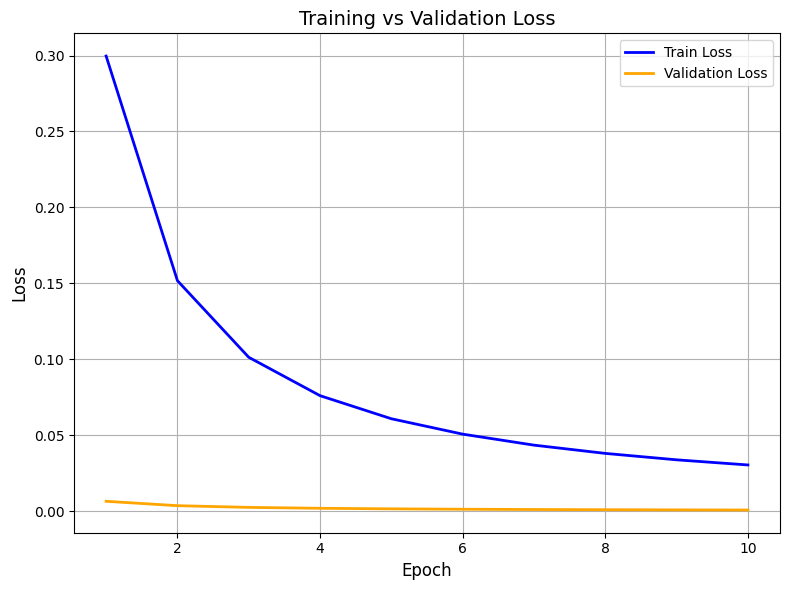

In [36]:
import matplotlib.pyplot as plt

def plot_loss_curves(train_metrics, val_metrics):
    plt.figure(figsize=(8, 6))

    epochs = range(1, len(train_metrics["loss_total"]) + 1)

    plt.plot(epochs, train_metrics["loss_total"], label="Train Loss", color="blue", linewidth=2)
    plt.plot(epochs, val_metrics["loss_total"], label="Validation Loss", color="orange", linewidth=2)

    plt.title("Training vs Validation Loss", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_loss_curves(train_metrics, val_metrics)

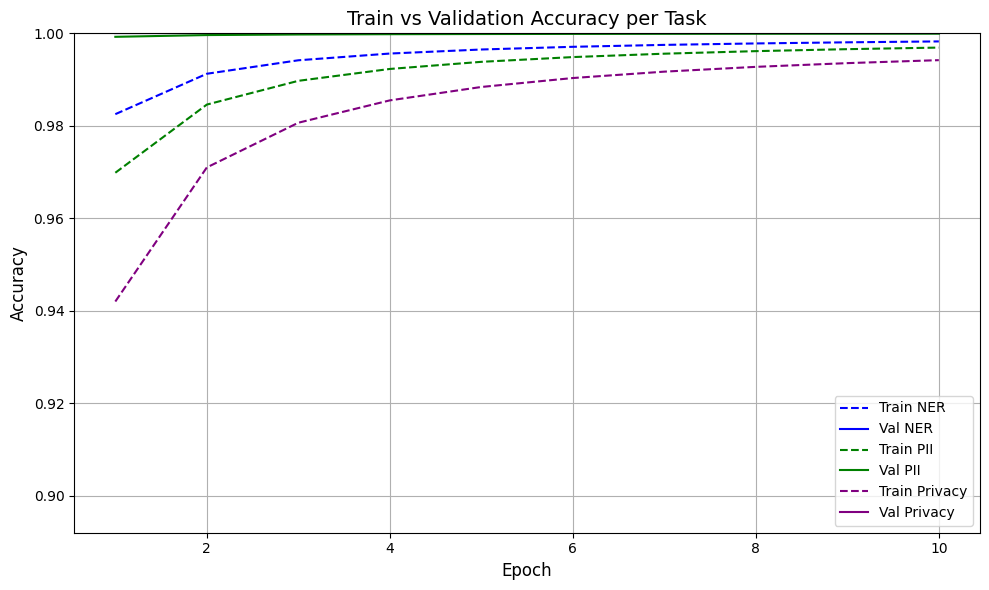

In [38]:
def plot_accuracy_curves(train_metrics, val_metrics):
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(train_metrics["acc_ner"]) + 1)

    # Combine all values to compute dynamic y-limits
    all_accs = (
        train_metrics["acc_ner"] + val_metrics["acc_ner"] +
        train_metrics["acc_pii"] + val_metrics["acc_pii"] +
        train_metrics["acc_privacy"] + val_metrics["acc_privacy"]
    )
    ymin = max(0.0, min(all_accs) - 0.05)
    ymax = min(1.0, max(all_accs) + 0.05)

    # Plot NER
    plt.plot(epochs, train_metrics["acc_ner"], label="Train NER", color="blue", linestyle="--")
    plt.plot(epochs, val_metrics["acc_ner"], label="Val NER", color="blue")

    # Plot PII
    plt.plot(epochs, train_metrics["acc_pii"], label="Train PII", color="green", linestyle="--")
    plt.plot(epochs, val_metrics["acc_pii"], label="Val PII", color="green")

    # Plot Privacy Classification
    plt.plot(epochs, train_metrics["acc_privacy"], label="Train Privacy", color="purple", linestyle="--")
    plt.plot(epochs, val_metrics["acc_privacy"], label="Val Privacy", color="purple")

    plt.title("Train vs Validation Accuracy per Task", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.ylim(ymin, ymax)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
plot_accuracy_curves(train_metrics, val_metrics)